# **AlTar 2 - a toy model with epistemic uncertainties**

# **Step 1 - prepare the input files**
---
### Understand the example: what do we want to do?

We consider a simple 2.5 dimensional model of a strike-slip fault that extends infinitely along strike. Strike-perpendicular and vertical directions are respectively defined by the $\mathbf{x}_1$ and $\mathbf{x}_2$ axes, the free surface being the $(\mathbf{x}_1$, $\mathbf{x}_3)$ plane (see Figure 1). The displacement on the fault is restricted to the $\mathbf{x}_3$ direction (i.e., along strike direction). Each surface displacement is calculated for a particular data point located at $x_1$ along the strike-perpendicular direction $\mathbf{x}_1$ (and then for $x_2 = 0$).

![Figure 1. ](intro_cp_fig.png)

The aim of this example is to provide the **AlTar** input and configuration files to solve for a synthetic test which includes epistemic uncertainties. The synthetic observations will be calculated for a heterogeneous medium, in which the fault bounds two media of different shear moduli. The assumed Green's functions will be calculated in an homogeneous half space, thus inducing epistemic uncertainties in the inverse problem (because the assumed medium does not correspond to the one used to calculate the synthetic data). We will thus calculate the corresponding prediction covariance matrix $\mathbf{C}_\mathrm{p}$ to account for these epistemic uncertainties.

In this example, we will:
- Run through the calculation of a synthetic dataset, using analytical expressions
- Calculate the Green's functions from analytical expressions, either for a homogeneous half space or for a heterogeneous medium.
- Calculate the sensitivity kernels of the Green's functions from analytical expressions, and calculate the prediction covariance matrix

The content is organized as follow:
1. Setup of the Toy Model
2. Calculate data and uncertainties for an heterogeneous medium
    1. Calculate the data from analytical expressions
    2. Calculate the data covariance matrix
    3. Plot the data
3. Calculate the Green's functions
    1. Heterogeneous Green's functions
    2. Homoegeneous Green's functions
    3. Compare Homogeneous and heterogeneous Green's functions
    4. Investigate the impact of the shear moduli ratio on Green's functions
4. Calculate the Prediction Covariance Matrix
    1. Calculate the seinsitivity kernels
    2. Setup the covariance of the shear moduli and the initial slip model
    3. Calculate the misfit covariance matrix
5. Export the **AlTar** input files
6. Configure **AlTar**

If you're not interested in the calculation of the synthetic dataset and Green's functions, you can jump directly to the sections where $\mathbf{C}_\mathrm{p}$, or where the **AlTar** input files are written.

> *Note: if you have any troubles understanding the concepts presented here, please refer to the **Altar** User Guide.*


### 1. Setup of the Toy Model

We begin by importing the necessary modules

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import mpmath

Then, we can define a name for our future test, which is also the name of the directory with the **AlTar** input files:

In [2]:
name = 'test1'

Let's define the parameters of the fault geometry we will assume. These parameters are:

In [3]:
length = 500000. # in km. The length is very long
width = 10000.  # in km. The width of a vertical fault is the depth it reaches.
nstrike = 1.  # subfault along strike
ndip = 20  # subfaults along dip. Each subfault is thus of 500 m x 250 km
strike = 0  # in degrees. It does not matter here
dip = 90.  # in degrees. We want a vertical fault

Np = int(ndip*nstrike*2)  # Np is the number of parameters of the model

The parameters of the crustal structure are:

In [4]:
mu1 = 2.0  # shear modulus on the West side of the fault
mu2 = 5.0  # on the right side

And the slip will be uniform on the fault, with no slip along dip. The slip along strike is:

In [5]:
s = 10.0  # in m.
d = width  # the slip is equall to s from 0 to depth d

### 2. Calculate data and uncertainties for an heterogeneous medium

#### 2.1 Calculate the data from analytical expressions

Now, we want to define our data points `x`, which will be distributed along a line perpendicular to the fault direction (along the $\mathbf{x}_1$ axis). We place them asymmetrically about the fault, 70 on the West side and 30 on the East side, as for a network that covers one side of the fault better than the other: with a symmetric network, the epistemic uncertainties of this toy model would only affect the fit to the data, not the inferred slip.

In [6]:
x = np.concatenate((np.linspace(-40000, -500, 70), np.linspace(500, 15000, 30)))


Following Segall (2010), we can derive the expression of the surface displacement produced by an infinitely long vertical strike-slip fault bounding two media of different shear modulus, $\mu_1$ and $\mu_2$. The slip $s$ on the fault extends from the free surface to depth $d$. We will refer to displacement $u^{(1)}$ on the side with modulus $\mu_1$, and to displacement $u^{(2)}$ on the side with modulus $\mu_2$.
\begin{equation}
\begin{split}
u^{(1)}\left(x_{1},  x_{2}=0\right)=   \frac{2 s}{\pi} \; \frac{\mu_2}{\mu_1 + \mu_2} \; \tan^{-1} \biggr( \frac{d}{x_{1}} \biggr) \\
u^{(2)}\left(x_{1},  x_{2}=0\right)=   \frac{2 s}{\pi} \; \frac{\mu_1}{\mu_1 + \mu_2} \; \tan^{-1} \biggr( \frac{d}{x_{1}} \biggr)
\end{split}
\end{equation}

Note that the displacement is along $\mathbf{x}_3$, is calculated at the free surface (so with $\mathbf{x}_2$=0), and only depends on $\mathbf{x}_1, the strike perpendicular direction.

We can create a function to calculate the surface displacement follwing this expression, for a particular data point `x_i`:

In [7]:
def calcSurfaceDispHet(x_i, s, d, mu1, mu2):
    '''
    Returns the surface displacement in meters.
    '''
    if x_i < 0:
        u = ((2*s) / np.pi) * (mu2 / (mu1 + mu2)) * np.arctan(d / x_i)
    else:
        u = ((2*s) / np.pi) * (mu1 / (mu1 + mu2)) * np.arctan(d / x_i)
    return float(u)

Now, we are able to calculate the surface displacement associated with the slip `s` at every data point.

In [8]:
u_x3 = []
for i in range(len(x)):
    if x[i] == 0:
        u_x3.append(0)
    else:
        u_x3.append( calcSurfaceDispHet(x[i], s, d, mu1, mu2) )

We can also add noise to our data. We assume the noise to be approximately 2% of the maximum surface displacement.


In [9]:
noise_amplitude = 0.02 * np.amax(u_x3)
print("noise amplitude (cm): ", noise_amplitude*100)

noise_type = 'no'

if noise_type == 'uncorrelated':
    noise = noise_amplitude*np.random.normal(0,1,len(u_x3))
elif noise_type == 'correlated':
    #### NOT SURE VERIFY
    A = np.zeros((len(u_x3), len(u_x3)))
    cov = [ [math.exp(- abs(i - j) / 200.) for i in range(len(u_x3))] for j in range(len(u_x3))]
    w, v = np.linalg.eig(cov)
    for i in range(len(u_x3)):
        for j in range(len(u_x3)):
            A[i, j] = sum(math.sqrt(w[k]) * v[i, k] * v[j, k] for k in range(len(u_x3)))
    x2 = 0.5 * noise_amplitude * np.random.normal(0, 1, len(u_x3))
    noiseuncorr = 0.5 * noise_amplitude * np.random.normal(0, 1, len(u_x3))
    noise = np.dot(A, x2) + noiseuncorr
elif noise_type == 'no':
    noise = np.zeros(np.shape(u_x3))
else:
    print("Please define noise_type")

u_x3 += noise

noise amplitude (cm):  5.532545699929413


As input for **AlTar**, we also need to define the surface displacement along the axes $\mathbf{x}_1$ (East) and $\mathbf{x}_2$ (Up).


In [10]:
u_x1 = np.zeros(np.shape(u_x3))
u_x2 = np.zeros(np.shape(u_x3))

And we prepare for use with **Altar** a vector `u` witch containes the displacements along East direction, along North, and the Vertical displacements.

In [11]:
u = np.concatenate( (u_x1, u_x3, u_x2), axis=0 )
print("Number of data: ",len(u))

Number of data:  300


#### 2.2 Calculate the data covariance matrix $\mathbf{C}_\mathrm{d}$

In this simple case, we assume that there is no covariance between the data points, and that their variance is uniform.

In [12]:
var_u = (0.05 * np.amax(u_x3))**2
Cd = np.diag( var_u * np.ones(np.shape(u)) )

#### 2.3 Plot the data

Let's plot the calculated surface displacement and its uncertainties in fonction of the distance from the fault:

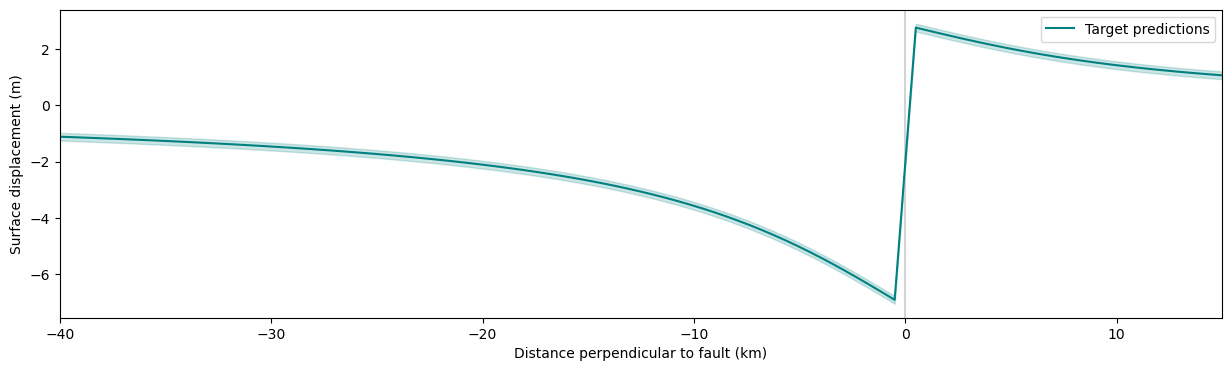

In [13]:
fig=plt.figure(figsize=(15,4))
plt.axvline(x=0,color='lightgray')
plt.fill_between(x/1000, u_x3 - np.sqrt(var_u), u_x3 + np.sqrt(var_u),color='teal', alpha=0.2)
plt.plot(x/1000, u_x3,color='teal',label='Target predictions')
plt.xlim([-40,15])
plt.xlabel('Distance perpendicular to fault (km)')
plt.ylabel('Surface displacement (m)')
plt.legend()
plt.show()

### 3. Calculate the Green's functions

#### 3.1 Heterogeneous Green's functions

From the expressions of the surface displacement presented above, we can derive the expression of the Green's functions and their derivatives. The Green's functions are the surface displacement induced by a unit slip on one subfault. We will consider a subfault $f_i$ of width $\delta d = d_{i+1} - d_i$, $d_{i+1} \ge d_i$. The Green's function $G(x_j, f_i)$ can be expressed as the difference between the surface displacement due to a finite dislocation between the free surface and depth $d_{i+1}$, and another finite dislocation between the free surface and depth $d_{i}$.

For an infinitely long vertical strike-slip fault bounding two media of different shear modulus, $\mu_1$ and $\mu_2$, we thus have:

\begin{equation}
\begin{split}
\mathbf{G}_v^{(1)}(x_j, f_i)  = u_v^{(1)}(x_{j}, d_{i+1}) - u_v^{(1)}(x_{j}, d_{i}) \\
\mathbf{G}_v^{(2)}(x_j, f_i)  = u_v^{(2)}(x_{j}, d_{i+1}) - u_v^{(2)}(x_{j}, d_{i})
\end{split}
\end{equation}	

\begin{equation}
\begin{split}
\mathbf{G}_v^{(1)}(x_j, f_i) = \frac{2}{\pi} \; \frac{\mu_2}{\mu_1 + \mu_2} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr] \\
\mathbf{G}_v^{(2)}(x_j, f_i) = \frac{2}{\pi} \; \frac{\mu_1}{\mu_1 + \mu_2} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr] 
\end{split}
\end{equation}	

In [14]:
def calcGFhet(x, mu1, mu2, width, ndip):
    '''
    Returns the GFs in meters
    '''
    d = np.linspace(0.,width,ndip+1)
    Gv = np.zeros((len(x),len(d)-1))
    for j in range(len(x)):
        # the side with mu1 (x < 0) moves with mu2/(mu1+mu2), the side with mu2 with mu1/(mu1+mu2)
        mu = mu2 if x[j] < 0 else mu1
        for i in range(0,len(d)-1):
            Gv[j,i] = (2/np.pi) *  (mu/(mu1+mu2)) * ( mpmath.atan(d[i+1]/x[j]) - mpmath.atan(d[i]/x[j]) )
    return Gv

## For the strike-slip component and the x3 (North) direction:
Gv_ss_x3 = calcGFhet(x, mu1, mu2, width, ndip)

## For the strike-slip component and the other directions:
Gv_ss_x1 = np.zeros( np.shape(Gv_ss_x3) )
Gv_ss_x2 = np.zeros( np.shape(Gv_ss_x3) )

## Full GFs for the strike-slip direction
Gv_ss = np.concatenate( (Gv_ss_x1, Gv_ss_x3, Gv_ss_x2), axis = 0)

## dip-slip direction:
Gv_ds = np.zeros( np.shape(Gv_ss) )

## Full GFs, (observations, strike-slip and dip-slip parameters)
Gv = np.concatenate( (Gv_ss, Gv_ds), axis = 1)

#### 3.2 Homogeneous Green's Functions

As for the heterogeneous case, the expression of the surface displacement for an infinite strike slip fault breaking the surface and embedded in a homogeneous half space is (Segall, 2010):
\begin{equation}
u_h\left(x_1, x_2=0\right) = \frac{s}{\pi} \tan^{-1} \left( \frac{d}{x_1} \right)
\end{equation}

> *Note that this displacement is similar to the heterogeneous case for $\mu_1 = \mu_2$.*

We can then derive the expression of the Green's Functions:
\begin{equation}
\mathbf{G}_h(x_j, f_i) = \frac{1}{\pi} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr] \\
\end{equation}	

In [15]:
def calcGFhom(x, width, ndip):
    '''
    Returns the GFs in meters
    '''
    d = np.linspace(0.,width,ndip+1)
    Gh = np.zeros((len(x),len(d)-1))
    for j in range(len(x)):
        for i in range(0,len(d)-1):
            Gh[j,i] = (1/np.pi) *  ( mpmath.atan(d[i+1]/x[j]) - mpmath.atan(d[i]/x[j]) )
    return Gh

In [16]:
## For the strike-slip component and the x3 (North) direction, homogeneous case:
Gh_ss_x3 = calcGFhom(x, width, ndip)

## And similarly to the previous case:
Gh_ss_x1 = np.zeros( np.shape(Gh_ss_x3) )
Gh_ss_x2 = np.zeros( np.shape(Gh_ss_x3) )
Gh_ss = np.concatenate( (Gh_ss_x1, Gh_ss_x3, Gh_ss_x2), axis = 0)
Gh_ds = np.zeros( np.shape(Gh_ss) )
Gh = np.concatenate( (Gh_ss, Gh_ds), axis = 1)

#### 3.3 Compare the homogeneous and heterogeneous Green's functions:

For the shallowest and the deepest sub-faults, we compare the homogeneous and heterogeneous Green's functions (we thus compare the surface displacement induced by a unit slip on each of these subfaults):

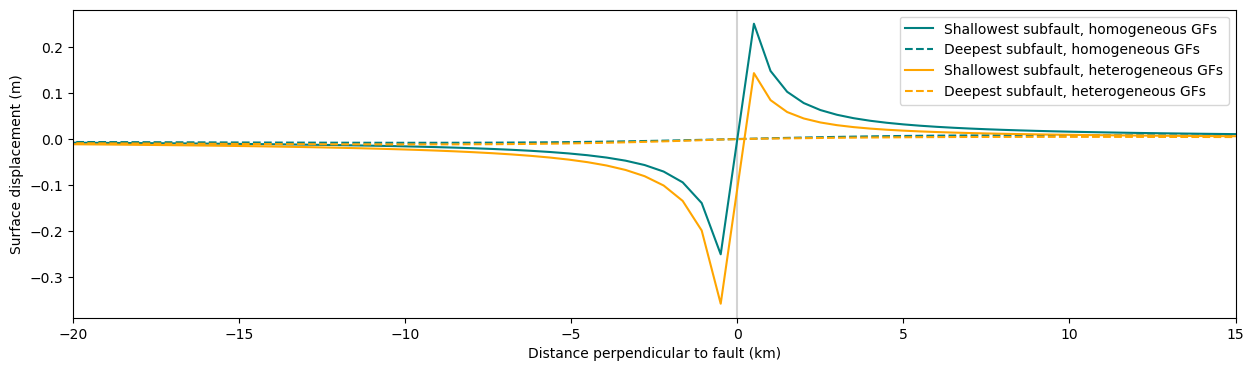

In [17]:
fig=plt.figure(figsize=(15,4))
plt.axvline(x=0,color='lightgray')
plt.plot(x/1000, Gh_ss_x3[:,0],color='teal',label='Shallowest subfault, homogeneous GFs')
plt.plot(x/1000, Gh_ss_x3[:,-1],'--',color='teal',label='Deepest subfault, homogeneous GFs')
plt.plot(x/1000, Gv_ss_x3[:,0],color='orange',label='Shallowest subfault, heterogeneous GFs')
plt.plot(x/1000, Gv_ss_x3[:,-1],'--',color='orange',label='Deepest subfault, heterogeneous GFs')
plt.xlim([-20,15])
plt.xlabel('Distance perpendicular to fault (km)')
plt.ylabel('Surface displacement (m)')
plt.legend()
plt.show()

#### 3.4 Investigate the impact of the shear moduli ratio on Green's functions

We can also investigate the impact of a variation of the shear moduli ratio ($\mu_2/\mu_1$) on the Green's functions. We calculate the Green's functions for a range of different $\mu_1$ and look at the evolution of the GFs for the shallowest and deepest subfaults:

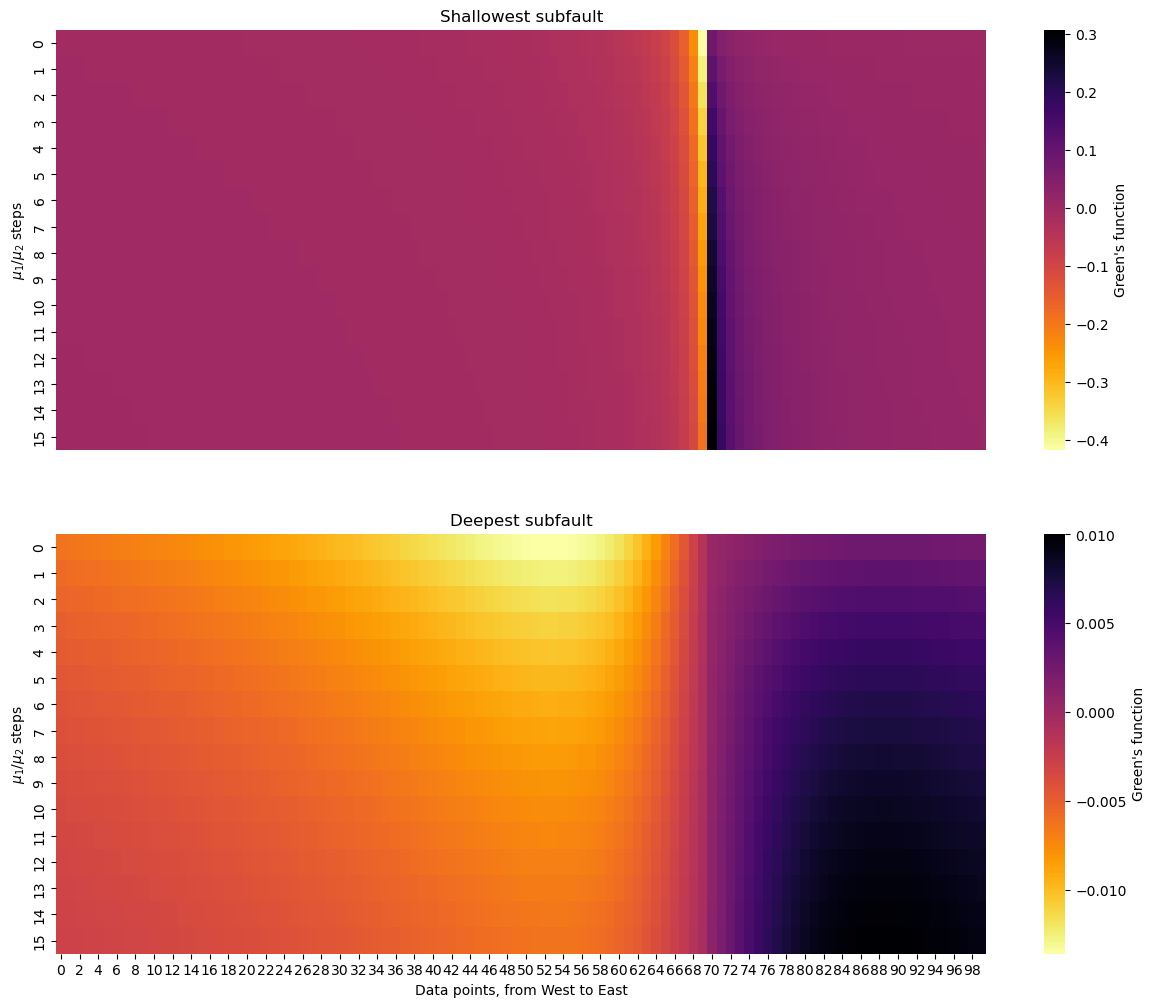

In [18]:
gfs = []
for mu_i in np.linspace(1.,8.,16):
    gfs.append(calcGFhet(x, mu_i, mu2, width, ndip))

fig = plt.figure(figsize=(15,12))
fig.add_subplot(2,1,1)
ax = sns.heatmap(np.array(gfs)[:,:,0],cmap='inferno_r',
            linewidths=.0, rasterized=True,xticklabels=False, 
            cbar_kws={'label': 'Green\'s function'})
plt.ylabel(r'$\mu_1/\mu_2$ steps')
plt.title('Shallowest subfault')

fig.add_subplot(2,1,2)
ax = sns.heatmap(np.array(gfs)[:,:,-1],cmap='inferno_r',
            linewidths=.0, rasterized=True, 
            cbar_kws={'label': 'Green\'s function'})
plt.ylabel(r'$\mu_1/\mu_2$ steps')
plt.xlabel('Data points, from West to East')
plt.title('Deepest subfault')
plt.show()

### 4. Calculate the Prediction Covariance Matrix $\mathbf{C}_\mathrm{p}$

#### 4.1 Calculate the sensitivity Kernels for $\mu_1$ and $\mu_2$

We can then derive the expressions of the sensitivity kernels of the Green's functions with respect to each shear modulus. As the shear modulus $\mu$ is a Jeffreys parameter (e.g., Tarantola, 2005), the generic expression of the sensitivity kernels is:

\begin{equation}
\mathbf{K_{\mu}}(x_j, f_i) = \frac{\partial \; \mathbf{G}(x_j, f_i)}{\partial \ln  \mu} = \frac{\partial \; \mathbf{G}(x_j, f_i)}{\partial \mu} \cdot \mu.
\end{equation}

We thus have:
\begin{equation}
\begin{split}
{}& \mathbf{K_{v, \mu_1}}^{(1)}(x_j, f_i) = - \frac{2}{\pi} \; \frac{\mu_1 \cdot \mu_2}{(\mu_1 + \mu_2)^{2}} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr] \\
& \mathbf{K_{v, \mu_1}}^{(2)}(x_j, f_i) = \frac{2}{\pi} \; \frac{\mu_1 \cdot \mu_2}{(\mu_1 + \mu_2)^{2}} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr]
\end{split}
\end{equation}

\begin{equation}
\begin{split}
{}& \mathbf{K_{v, \mu_2}}^{(1)}(x_j, f_i) = \frac{2}{\pi} \; \frac{\mu_1 \cdot \mu_2}{(\mu_1 + \mu_2)^{2}} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr] \\
& \mathbf{K_{v, \mu_2}}^{(2)}(x_j, f_i) = - \frac{2}{\pi} \; \frac{\mu_1 \cdot \mu_2}{(\mu_1 + \mu_2)^{2}} \; \biggr[ \tan^{-1} \biggr( \frac{d_{i+1}}{x_{j}} \biggr) - \tan^{-1} \biggr( \frac{d_{i}}{x_{j}} \biggr) \biggr]
\end{split}
\end{equation}

> *Note that on each side of the fault the two kernels cancel: scaling both shear moduli by the same factor does not change the Green's functions.*

In [19]:
def calcKhet(x, mu1, mu2, width, ndip):
    '''
    Returns the sensitivity kernels dG/dln(mu1) and dG/dln(mu2)
    '''
    d = np.linspace(0.,width,ndip+1)
    Kv1 = np.zeros((len(x),len(d)-1))  # the kernel for mu1
    Kv2 = np.zeros((len(x),len(d)-1))  # the kernel for mu2
    c = (2 / np.pi) * (mu1 * mu2) / (mu1 + mu2) ** 2
    for j in range(len(x)):
        # on the side with mu1 (x < 0), G decreases with mu1 and increases with mu2; the reverse on the other side
        sign = -1 if x[j] < 0 else 1
        for i in range(0,len(d)-1):
            Kv1[j, i] = sign * c * (mpmath.atan(d[i + 1] / x[j]) - mpmath.atan(d[i] / x[j]))
            Kv2[j, i] = - Kv1[j, i]
    K = [Kv1]
    K.append(Kv2)
    return K

K = calcKhet(x, mu1, mu2, width, ndip)

We can check the kernels against finite differences of the heterogeneous Green's functions:

In [20]:
h = 1e-6
dG_mu1 = (calcGFhet(x, mu1*np.exp(h), mu2, width, ndip) - Gv_ss_x3) / h
dG_mu2 = (calcGFhet(x, mu1, mu2*np.exp(h), width, ndip) - Gv_ss_x3) / h
print("largest difference, mu1 kernel:", np.abs(dG_mu1 - K[0]).max())
print("largest difference, mu2 kernel:", np.abs(dG_mu2 - K[1]).max())

largest difference, mu1 kernel: 2.189698544707852e-08
largest difference, mu2 kernel: 2.1873557298768276e-08


#### 4.2 Setup the covariance of the shear moduli and the initial slip model

> *Note that here, we assume an initial model that is different from the target slip model*

In [21]:
Cov = np.diag( 0.1 * np.ones(np.shape(K)[0]))
inimodel = (s/2) * np.ones((Np//2,)) # only for the strike-slip components!

#### 4.3 Calculate $\mathbf{C}_\mathrm{\chi}$

One option when including $\mathbf{C}_\mathrm{p}$ in **AlTar** is to incorporate it directly in the misfit covariance matrix $\mathbf{C}_\mathrm{\chi}$ (see **User Guide, section Epistemic Uncertainties**). 

In [22]:
def calcCp(K,Cov,mprior):
    '''
    K : tensor of kernels
    Cov : covariance matrix (array)
    mprior : array
    '''
    k = np.transpose(np.matmul(K, mprior))
    C1 = np.matmul(k, Cov)
    Cp = np.matmul(C1, np.transpose(k))
    return Cp

Cp_x3 = calcCp(K,Cov,inimodel)

We have calculated $\mathbf{C}_\mathrm{p}$ for the $\mathbf{x}_3$ component only. The full matrix is:

In [23]:
Cp = np.block([[ np.zeros(np.shape(Cp_x3)) ,  np.zeros(np.shape(Cp_x3)), np.zeros(np.shape(Cp_x3)) ],
               [ np.zeros(np.shape(Cp_x3)) ,         Cp_x3             , np.zeros(np.shape(Cp_x3)) ],
               [ np.zeros(np.shape(Cp_x3)) ,  np.zeros(np.shape(Cp_x3)), np.zeros(np.shape(Cp_x3)) ]])

Cx = Cp + Cd

The other option is to recalculate $\mathbf{C}_\mathrm{p}$ during the sampling, from the current mean model. In this case, **AlTar** needs as distinct input files: the sensitivity kernels, the covariance matrix of the shear moduli, and the initial model.

### 5. Export input files for **AlTar**

We write the input files to the directory `test1`, with the names the static model `altar.models.seismic.static` looks for by default. First, we export the synthetic dataset and related uncertainties, and the homogeneous Green's functions.

In [24]:
os.makedirs(name, exist_ok=True)

with h5py.File(os.path.join(name, 'static.data.h5'), 'w') as hf:
    hf.create_dataset('data', data=u)

with h5py.File(os.path.join(name, 'static.Cd.h5'), 'w') as hf:
    hf.create_dataset('data errors', data=Cd)

with h5py.File(os.path.join(name, 'static.gf.h5'), 'w') as hf:
    hf.create_dataset('GFs', data=Gh_ss)    ## in this case the only estimated parameters will be the strike-slip components

Now we can export either $\mathbf{C}_\mathrm{\chi}$ (that will replace $\mathbf{C}_\mathrm{d}$), or the other files for the second option. **AlTar** expects one kernel for each shear modulus, of the same shape as the Green's functions, so we pad ours, calculated for the $\mathbf{x}_3$ component only, with zeros for the other two components:

In [25]:
with h5py.File(os.path.join(name, 'static.Cx.h5'), 'w') as hf:
    hf.create_dataset('misfit covariance', data=Cx)

with h5py.File(os.path.join(name, 'static.kernel.h5'), 'w') as hf:
    for i in range(np.shape(K)[0]):
        zeros = np.zeros(np.shape(K[i]))
        hf.create_dataset('K'+str(i), data=np.concatenate((zeros, K[i], zeros), axis=0))

with h5py.File(os.path.join(name, 'static.initialModel.h5'), 'w') as hf:
    hf.create_dataset('mprior', data=inimodel)

with h5py.File(os.path.join(name, 'static.Cmu.h5'), 'w') as hf:
    hf.create_dataset('Cp covariance', data=Cov)

### 6. Configure **AlTar**

First, we print some values to help us fill in the configuration files:

In [26]:
print('patches = ', Np//2)
print('observations = ', len(u))
print('GFs = ',np.shape(Gh_ss))  ## reminder: only the strike-slip components here!

## calculate the moment M0 = mu A D and Mw, for the distribution of the initial samples
area = (width/ndip)*(length/nstrike) / 1e6  # the area of each patch in km2
M0 = 30e9 * (Np//2) * area * 1e6 * s  # in N.m, for a shear modulus of 30 GPa
Mw = (np.log10(M0) - 9.1) / 1.5
print('Mw = ', Mw)
print('patches area (km2) = ', area)

patches =  20
observations =  300
GFs =  (300, 20)
Mw =  8.050727506037122
patches area (km2) =  250.0


The configuration files, and the runs, are in the `step 2` notebook. They use the static model `altar.models.seismic.static`, with
- the input files in `test1`, the value of `model.case`;
- a single parameter set, `strikeslip`, for the slips of the 20 patches;
- a preparation distribution to initialize the samples from the seismic moment, `altar.models.seismic.moment`, with `Mw_mean` and the area of the patches from above;
- a Gaussian prior distribution centered on the target slip;
- and, for the second option, `model.cp = altar.models.cp.adaptive` to update $\mathbf{C}_\mathrm{p}$ during the sampling, with the kernels in `model.kmu_file`, the covariance of the shear moduli in `model.cmu_file`, and the initial model in `model.cp.initial_model`.

See the chapter [Model Uncertainty](../../guide/StaticCp.md) of the **AlTar** User Guide for all the settings.